In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
from sklearn.model_selection import train_test_split

**k-meansクラスタリング**

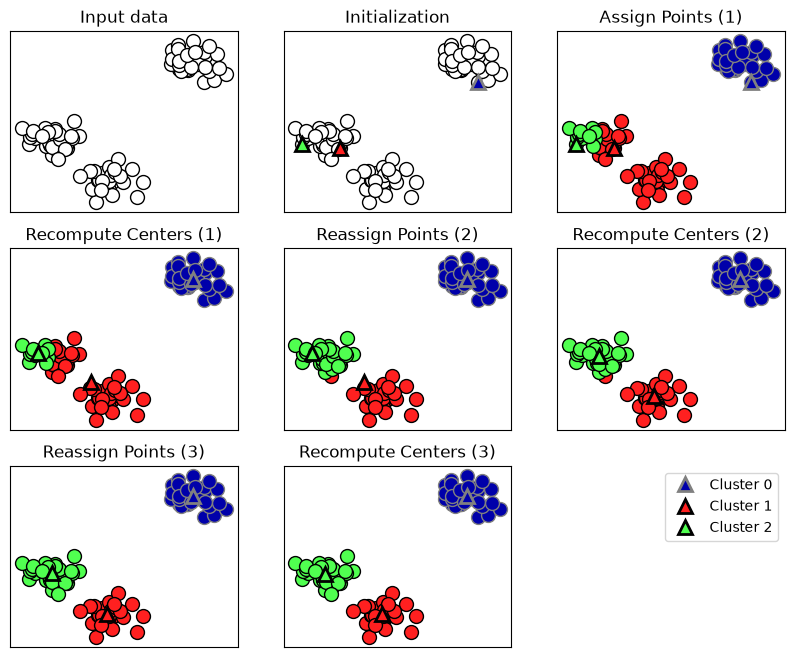

In [2]:
mglearn.plots.plot_kmeans_algorithm()

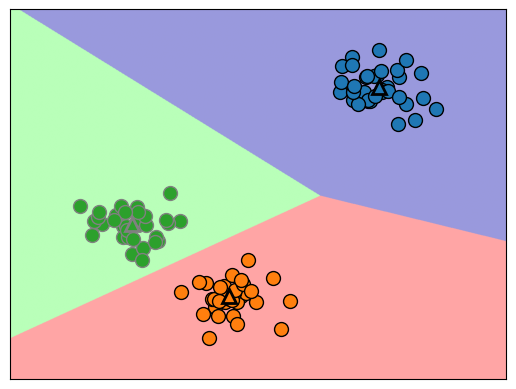

In [3]:
#クラスタセンタの境界を示す
mglearn.plots.plot_kmeans_boundaries()
plt.show()

In [4]:
#k-meansのクラスタリングを行う
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

x,y = make_blobs(random_state=1)

kmeans = KMeans(n_clusters=3)
kmeans.fit(x)
print("Cluster memberships:\n{}".format(kmeans.labels_))

Cluster memberships:
[0 1 1 1 2 2 2 1 0 0 1 1 2 0 2 2 2 0 1 1 2 1 2 0 1 2 2 0 0 2 0 0 2 0 1 2 1
 1 1 2 2 1 0 1 1 2 0 0 0 0 1 2 2 2 0 2 1 1 0 0 1 2 2 1 1 2 0 2 0 1 1 1 2 0
 0 1 2 2 0 1 0 1 1 2 0 0 0 0 1 0 2 0 0 1 1 2 2 0 2 0]


In [5]:
#訓練セットに対してpredictを行うと、kmeans.labels_と同じ結果が得られる
print(kmeans.predict(x))

[0 1 1 1 2 2 2 1 0 0 1 1 2 0 2 2 2 0 1 1 2 1 2 0 1 2 2 0 0 2 0 0 2 0 1 2 1
 1 1 2 2 1 0 1 1 2 0 0 0 0 1 2 2 2 0 2 1 1 0 0 1 2 2 1 1 2 0 2 0 1 1 1 2 0
 0 1 2 2 0 1 0 1 1 2 0 0 0 0 1 0 2 0 0 1 1 2 2 0 2 0]


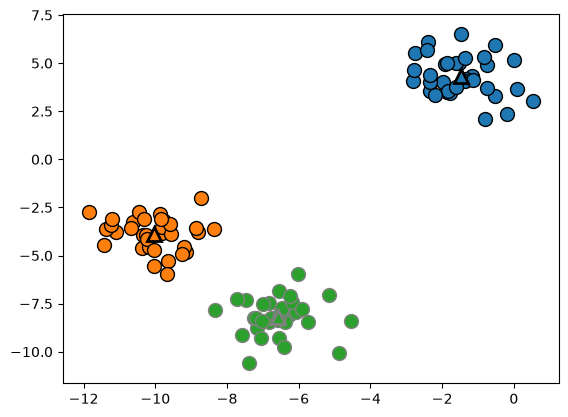

In [6]:
mglearn.discrete_scatter(x[:, 0], x[:, 1], kmeans.labels_, markers='o')
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2],
    markers='^', markeredgewidth=2)
plt.show()

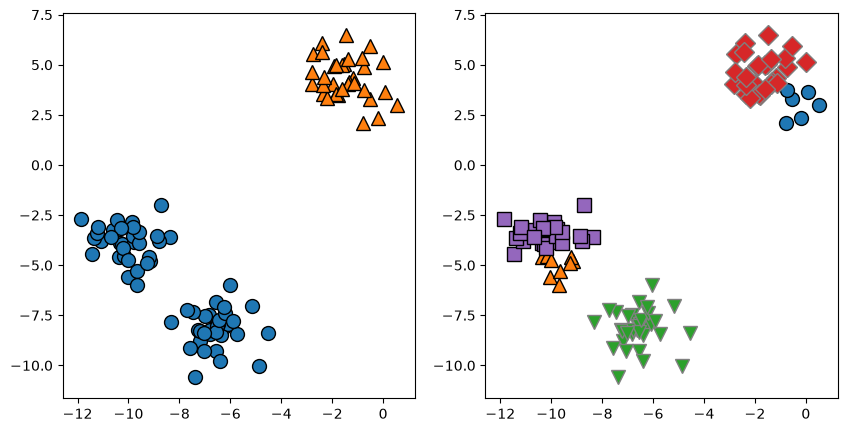

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

kmeans = KMeans(n_clusters=2)
kmeans.fit(x)
assignments = kmeans.labels_
mglearn.discrete_scatter(x[:, 0], x[:, 1], assignments, ax=axes[0])

kmeans = KMeans(n_clusters=5)
kmeans.fit(x)
assignments = kmeans.labels_
mglearn.discrete_scatter(x[:, 0], x[:, 1], assignments, ax=axes[1])

plt.show()

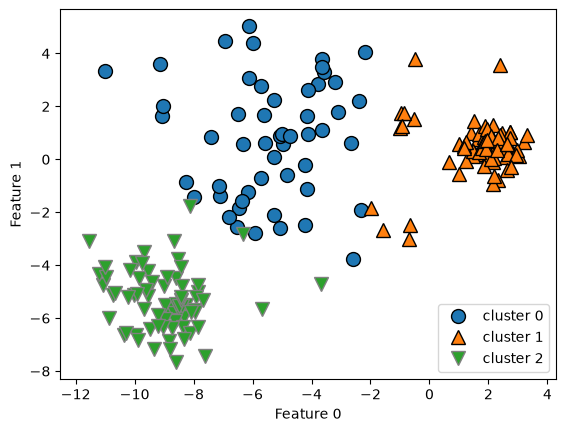

In [8]:
#k-meansでは比較的単純な形しか表現できない
#K-meansは「丸っぽく、同程度の大きさ・密度のクラスタ」には強いが、
# クラスタの大きさや広がりが大きく異なるデータでは、直感的なグループ分けとズレることがある。

x_varied,y_varied = make_blobs(n_samples=200, 
                               cluster_std=[1.0,2.5,0.5], 
                               random_state=170
                               )

y_pred = KMeans(n_clusters=3, random_state=0).fit_predict(x_varied)
mglearn.discrete_scatter(x_varied[:, 0], x_varied[:, 1], y_pred)
plt.legend(["cluster 0", "cluster 1", "cluster 2"], loc="best")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

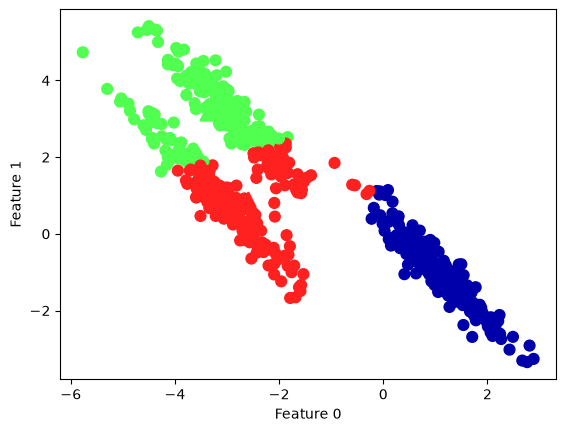

In [9]:
#k-meansは最も近いクラスタセンタへの距離しか考慮しないので、このようなデータを取り扱うことはできない
#k-meansは丸くないクラスタを識別できない

#ランダムにクラスタデータを生成
x,y = make_blobs(n_samples=600,
                 random_state=170
)
rng = np.random.RandomState(74)

#回転・拡大縮小・せん断などが混ざった線形変換をする
taransformation = rng.normal(size=(2,2))
x = np.dot(x, taransformation)

#データポイントを３つにクラスタリング
kmeans = KMeans(n_clusters=3)
kmeans.fit(x)
y_pred = kmeans.predict(x)

#クラスタ割り当てとクラスタセンタをプロット
plt.scatter(x[:, 0], x[:, 1], c=y_pred, s=60, cmap=mglearn.cm3)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='^', c=[0, 1, 2], s=100, linewidth=2, cmap=mglearn.cm3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()



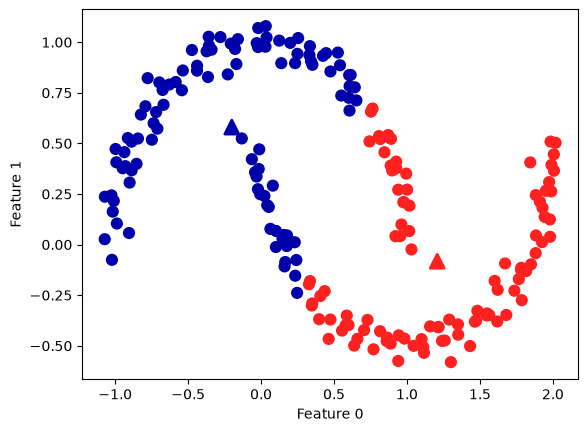

In [10]:
#k-means法はクラスタが複雑な形の場合もうまく機能しない
from sklearn.datasets import make_moons
x,y = make_moons(n_samples=200, noise=0.05, random_state=0)

kmeans = KMeans(n_clusters=2)
kmeans.fit(x)
y_pred = kmeans.predict(x)


plt.scatter(x[:, 0], x[:, 1], c=y_pred, s=60, cmap=mglearn.cm2)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='^', c=[0, 1], s=100, linewidth=2, cmap=mglearn.cm2)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

In [59]:
#PCA,NMFとk-means法を抽出された成分で比較してみよう

from sklearn.decomposition import NMF
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_lfw_people

people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)

mask = np.zeros(people.target.shape, dtype=np.bool)
for target in np.unique(people.target):
    mask[np.where(people.target == target)[0][:50]] = 1
    
X_people = people.data[mask]
y_people = people.target[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_people, y_people, stratify=y_people, random_state=0)
nmf = NMF(n_components=100, random_state=0)
nmf.fit(X_train)
pca = PCA(n_components=100, random_state=0)
pca.fit(X_train)
kmeans = KMeans(n_clusters=100, random_state=0)
kmeans.fit(X_train)

X_reconstructed_pca = pca.inverse_transform(pca.transform(X_test))
X_reconstructed_kmeans = kmeans.cluster_centers_[kmeans.predict(X_test)]
X_reconstructed_nmf = np.dot(nmf.transform(X_test), nmf.components_)

c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


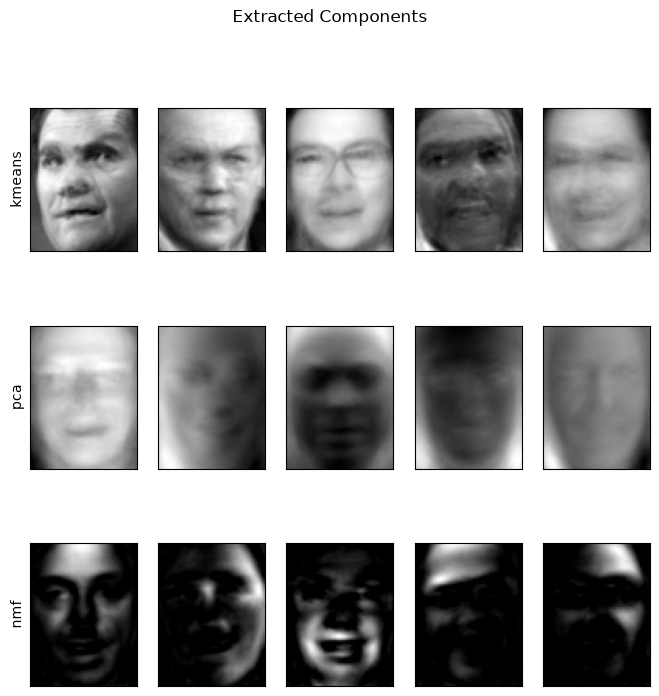

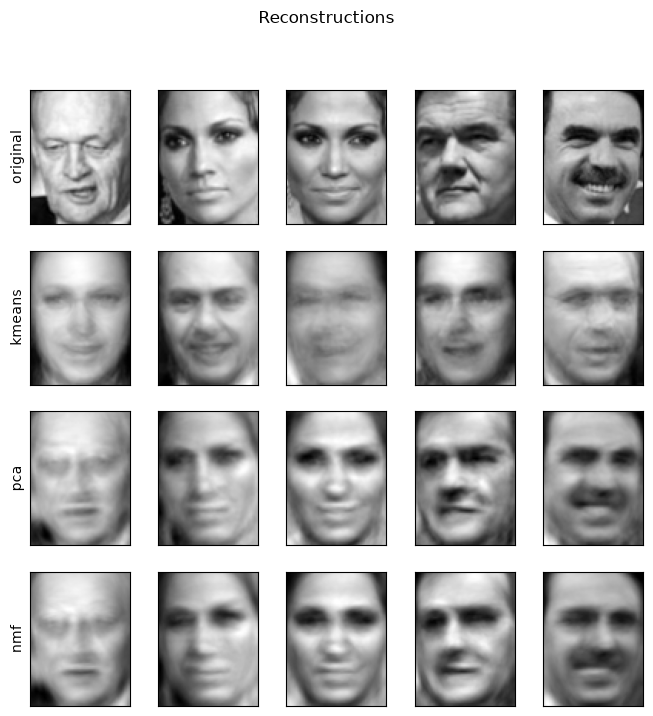

In [67]:
#PCA,NMFとk-means法を抽出された成分で比較してみる
#Meansによるベクトル量子化は、各データを「最も近いクラスタ中心1個」で表現する

from sklearn.datasets import fetch_lfw_people
people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
image_shape = people.images[0].shape

fig, axes = plt.subplots(3, 5, figsize=(8, 8),
                         subplot_kw={'xticks': (), 'yticks': ()})
fig.suptitle("Extracted Components")
for ax, comp_kmeans, comp_pca, comp_nmf in zip(
        axes.T, kmeans.cluster_centers_, pca.components_, nmf.components_):
    ax[0].imshow(comp_kmeans.reshape(image_shape), cmap='gray')
    ax[1].imshow(comp_pca.reshape(image_shape) , cmap='gray')
    ax[2].imshow(comp_nmf.reshape(image_shape) , cmap='gray')

axes[0, 0].set_ylabel("kmeans")
axes[1, 0].set_ylabel("pca")
axes[2, 0].set_ylabel("nmf")

fig, axes = plt.subplots(4, 5, subplot_kw={'xticks': (), 'yticks': ()},
                         figsize=(8, 8))
fig.suptitle("Reconstructions")
for ax, orig, rec_kmeans, rec_pca, rec_nmf in zip(
        axes.T, X_test, X_reconstructed_kmeans, X_reconstructed_pca,
        X_reconstructed_nmf):

    ax[0].imshow(orig.reshape(image_shape), cmap='gray')
    ax[1].imshow(rec_kmeans.reshape(image_shape), cmap='gray')
    ax[2].imshow(rec_pca.reshape(image_shape), cmap='gray')
    ax[3].imshow(rec_nmf.reshape(image_shape), cmap='gray')

axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("kmeans")
axes[2, 0].set_ylabel("pca")
axes[3, 0].set_ylabel("nmf")
plt.show()

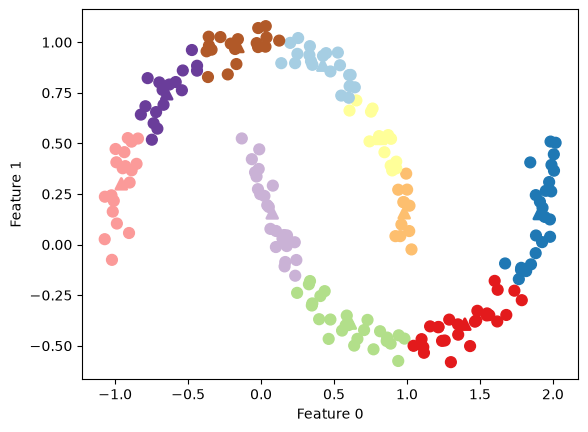

Cluster memberships:
[8 4 6 3 1 1 5 2 8 4 9 2 1 4 7 5 0 2 0 7 1 2 0 4 9 6 1 1 6 0 8 9 2 6 8 1 2
 5 3 6 2 7 8 6 4 9 5 7 6 2 7 2 1 3 4 8 0 4 0 9 2 3 1 8 4 3 9 4 9 3 2 3 2 6
 2 3 6 8 0 2 1 9 2 1 6 9 5 9 2 1 0 5 1 7 1 1 4 2 3 6 4 1 9 5 3 6 3 7 4 0 7
 9 9 3 8 4 8 1 2 8 8 7 6 9 6 7 5 6 4 1 5 7 3 6 4 4 4 3 1 8 6 6 0 9 7 5 6 4
 0 6 2 4 8 0 2 9 4 2 0 0 6 4 0 4 2 1 0 2 4 2 0 3 3 7 6 2 1 7 7 0 4 3 1 4 1
 0 9 2 3 7 3 0 8 5 6 7 1 6 9 4]


In [ ]:
#k-means法で多数のクラスタセンタを用いると、もっと強力な表現を見つけることができる
#元の二次元のデータを、クラスタセンタの数だけの次元に変換することで、より複雑な形状のデータを表現できるようになる。

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

kmeans = KMeans(n_clusters=10, random_state=0)
kmeans.fit(X)
y_pred = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=60, cmap='Paired')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=60,
            marker='^', c=range(kmeans.n_clusters), linewidth=2, cmap='Paired')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()
print("Cluster memberships:\n{}".format(y_pred))

In [ ]:
#さらに、個々のクラスタセンタを特徴量として用いることで、より複雑な形状のデータを表現できるようになる。

#transform(X) は、各データについてクラスタ中心それぞれまでの距離を計算する
#これにより、元の二次元のデータを、クラスタセンタの数だけの次元に変換することができる
distance_features = kmeans.transform(X)
print("Original shape: {}".format(X.shape))
print("Transformed shape: {}".format(distance_features.shape))
print("Distance features:\n{}".format(distance_features))

Original shape: (200, 2)
Transformed shape: (200, 10)
Distance features:
[[0.53664613 1.15017588 0.93237626 ... 1.48034956 0.002907   1.07736639]
 [1.74138152 0.60592307 1.00666225 ... 2.52921971 1.20779969 2.23716489]
 [0.75710543 1.93145038 0.91586549 ... 0.78321505 0.87573753 0.71838465]
 ...
 [0.9274342  1.73811046 0.57899268 ... 1.11471941 0.83358544 1.04125672]
 [0.3227627  1.97647071 1.47861069 ... 0.81425026 0.84551232 0.28446737]
 [1.63322944 0.47226506 1.02289983 ... 2.46626118 1.09767675 2.14812753]]


**疑集型クラスタリング**

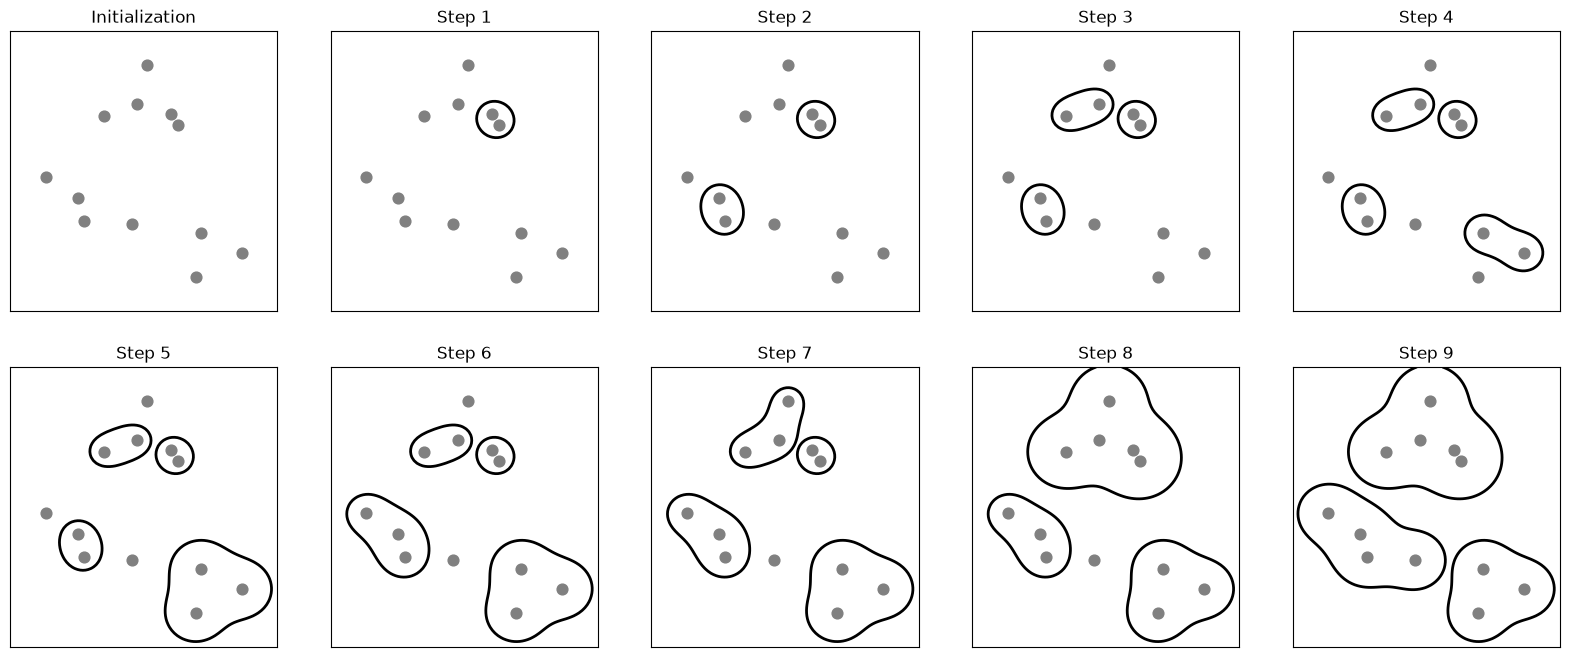

In [ ]:
#wardで、疑似的なクラスタを結合していくことで、より複雑な形状のデータを表現できるようになる。
#クラスタ数が３つになるところで終了
mglearn.plots.plot_agglomerative_algorithm()
plt.show()

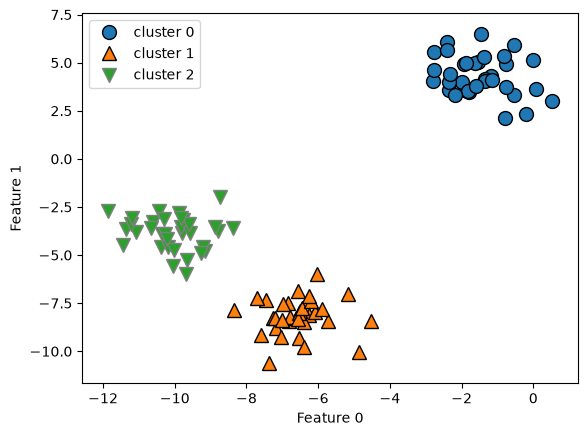

In [ ]:
#疑集合クラスタリングは新しいデータに対して予測することができない
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

x,y = make_blobs(random_state=1)
agg = AgglomerativeClustering(n_clusters=3)
assignments = agg.fit_predict(x)

mglearn.discrete_scatter(x[:, 0], x[:, 1], assignments)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["cluster 0", "cluster 1", "cluster 2"], loc="best")
plt.show()

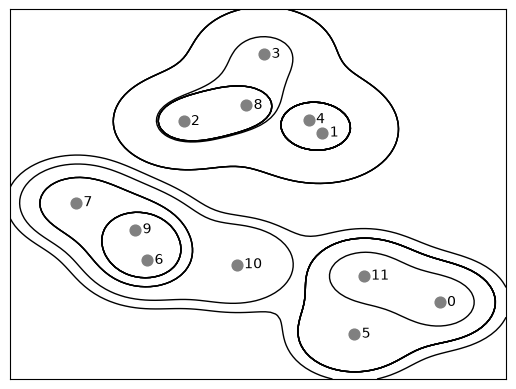

In [ ]:
#階層型クラスタリング
#ステップごとにクラスタの数が減っていく過程で得られる、全てのクラスタを重ねて表示する

mglearn.plots.plot_agglomerative()
plt.show()

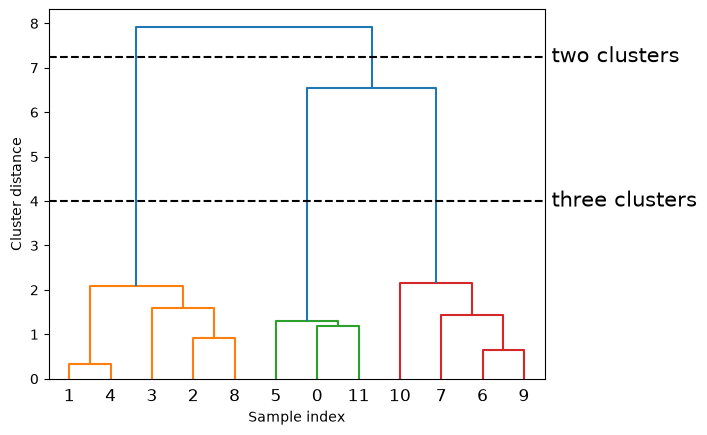

In [ ]:
#階層型クラスタをデンドログラムによって可視化
#木構造としてプロットする

from scipy.cluster.hierarchy import dendrogram, ward
X, y = make_blobs(random_state=0, n_samples=12)

#scipyのward関数は、凝集型クラスタリングを行った際のブリッジ距離の配列
linkage_array = ward(X)
#クラスタ間距離をデンドログラムとしてプロット
dendrogram(linkage_array)

ax = plt.gca()
bounds = ax.get_xbound()
ax.plot(bounds, [7.25, 7.25], '--', c='k')
ax.plot(bounds, [4, 4], '--', c='k')

ax.text(bounds[1], 7.25, ' two clusters', va='center', fontdict={'size': 15})
ax.text(bounds[1], 4, ' three clusters', va='center', fontdict={'size': 15})
plt.xlabel("Sample index")
plt.ylabel("Cluster distance")
plt.show()

-------------------------------------------------------------

**DBSCAN**

In [ ]:
from sklearn.cluster import DBSCAN
x,y = make_blobs(random_state=0, n_samples=12)

dbscan = DBSCAN()
clusters = dbscan.fit_predict(x)

#すべてのデータポイントがノイズを表すー１になっている
#これはmin_samplesのデフォルト設定が小さいトイデータセットに適していないため
print("Cluster memberships:\n{}".format(clusters))

Cluster memberships:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


min_samples: 2 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 2 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 2 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 2 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 3 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 3 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 3 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 3 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 5 eps: 1.000000  cluster: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
min_samples: 5 eps: 1.500000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 2.000000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]


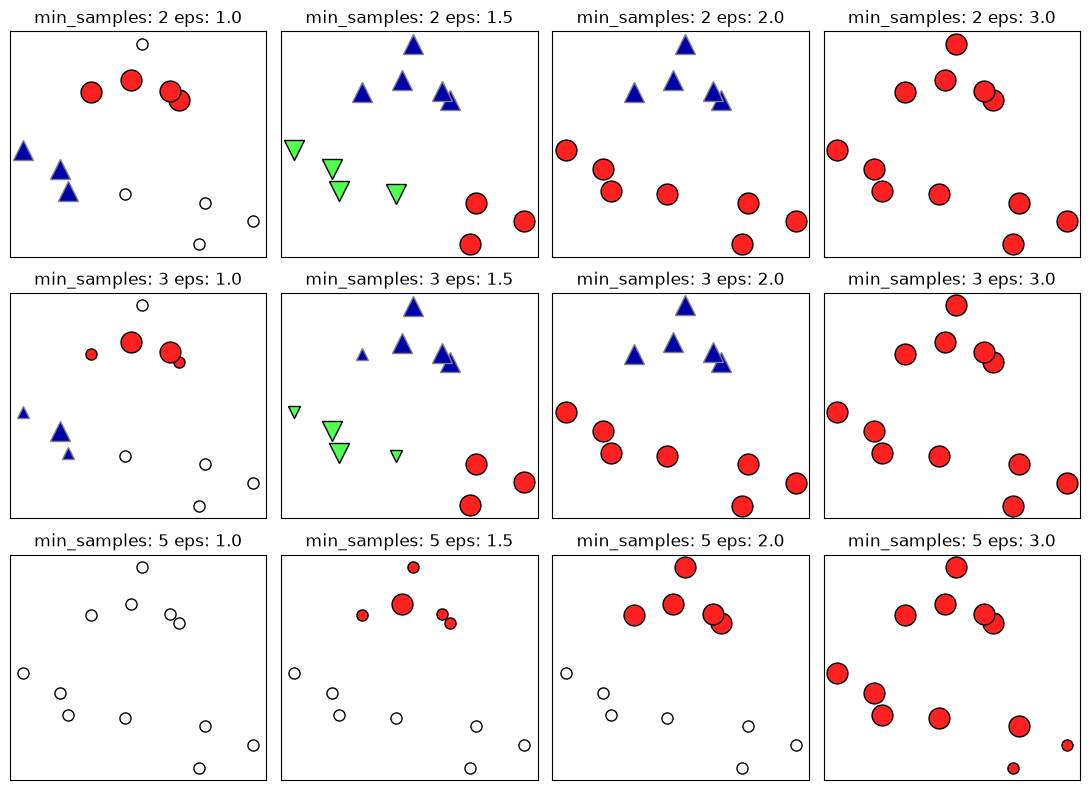

In [ ]:
#min_samplesとepsを様々な値に設定したものを示す
mglearn.plots.plot_dbscan()

Text(0, 0.5, 'Feature 1')

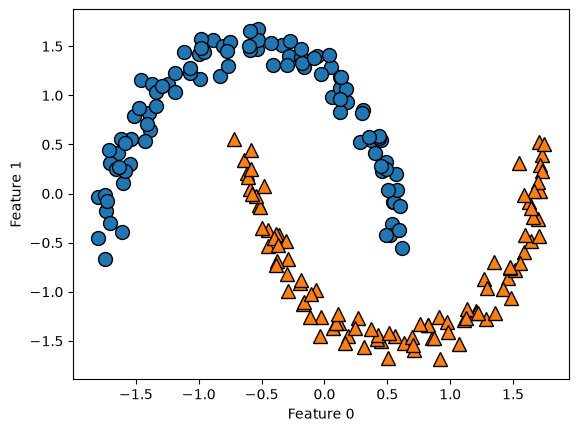

In [ ]:
#DBSCANをtwo_moonsデータセットに適用してみる
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

x,y = make_moons(n_samples=200, noise=0.05, random_state=0)

#データを平均１、標準偏差０に正規化する
scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)

dbscan = DBSCAN()
clusters = dbscan.fit_predict(x_scaled)

#クラスタリングの結果をプロット
# DBSCANは「データの密度」を利用するため、two_moonsのような曲がった形のクラスタも分離できる
mglearn.discrete_scatter(x_scaled[:, 0], x_scaled[:, 1], clusters)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")



**クラスタリングアルゴリズムの比較と評価**

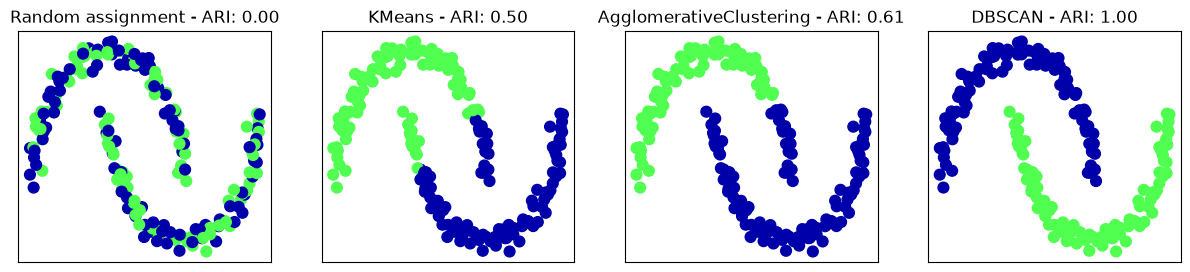

In [16]:
#クラスタリングの結果を評価するために、調整ランド指数(ARI)を用いる

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics.cluster import adjusted_rand_score

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

fig, axes = plt.subplots(1, 4, figsize=(15, 3),
                         subplot_kw={'xticks': (), 'yticks': ()})

algorithms = [KMeans(n_clusters=2), AgglomerativeClustering(n_clusters=2),
              DBSCAN()]

random_state = np.random.RandomState(seed=0)
random_clusters = random_state.randint(low=0, high=2, size=len(X))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=random_clusters,
                cmap=mglearn.cm3, s=60)
axes[0].set_title("Random assignment - ARI: {:.2f}".format(
        adjusted_rand_score(y, random_clusters)))

for ax, algorithm in zip(axes[1:], algorithms):
    clusters = algorithm.fit_predict(X_scaled)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters,
               cmap=mglearn.cm3, s=60)
    ax.set_title("{} - ARI: {:.2f}".format(algorithm.__class__.__name__,
                                           adjusted_rand_score(y, clusters)))
plt.show()

In [17]:
from sklearn.metrics import accuracy_score

#この２つのラベルは、同じクラスタリングを表している
clusters1 = [0,0,1,1,0]
clusters2 = [1,1,0,0,1]

#ラベルにまったく一致していないため、精度はゼロになる
print("Accuracy score: {:.2f}".format(accuracy_score(clusters1, clusters2)))

#クラスタリングは同じなため、ARIスコアは１になる
print("Adjusted Rand index: {:.2f}".format(adjusted_rand_score(clusters1, clusters2)))

Accuracy score: 0.00
Adjusted Rand index: 1.00


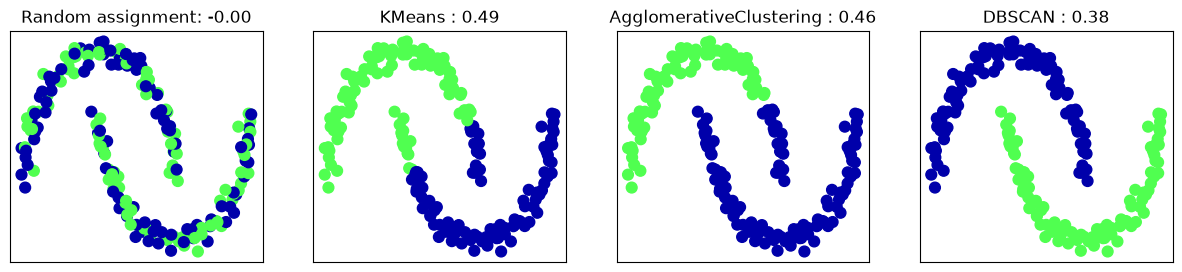

In [ ]:
#クラスタリングの結果を評価するために、シルエット係数を用いる
#しかし、複雑な形状のクラスタリングでは、シルエット係数は必ずしも直感的なクラスタリングの良さを反映しないことがある

from sklearn.metrics.cluster import silhouette_score

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

fig, axes = plt.subplots(1, 4, figsize=(15, 3),
                         subplot_kw={'xticks': (), 'yticks': ()})

random_state = np.random.RandomState(seed=0)
random_clusters = random_state.randint(low=0, high=2, size=len(X))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=random_clusters,
                cmap=mglearn.cm3, s=60)
axes[0].set_title("Random assignment: {:.2f}".format(
    silhouette_score(X_scaled, random_clusters)))

algorithms = [KMeans(n_clusters=2), AgglomerativeClustering(n_clusters=2),
              DBSCAN()]

for ax, algorithm in zip(axes[1:], algorithms):
    clusters = algorithm.fit_predict(X_scaled)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap=mglearn.cm3,
               s=60)
    ax.set_title("{} : {:.2f}".format(algorithm.__class__.__name__,
                                      silhouette_score(X_scaled, clusters)))
plt.show()

In [19]:
#k-means法、DBSCAN、階層型クラスタリングをLabeled Face in the Wildデータセットに適用して、
# 何らかの興味深い構造を見つけられるか試してみる
#ここでは、PCA(whiten=True)で生成された１００成分の固有顔を用いる

#lwf_peopleデータから固有顔を抽出し、変換する
from sklearn.decomposition import PCA

pca = PCA(
    n_components=100,
    whiten=True,
    random_state=0
)

pca.fit(X_people)
X_pca = pca.transform(X_people)

**DBSCAN**

In [ ]:
#デフォルト設定でDBSCANを適用する
dbscan = DBSCAN()
labels = dbscan.fit_predict(X_pca)
print("Uniqure labels: {}".format(np.unique(labels)))

Uniqure labels: [-1]


In [21]:
#すべてのデータポイントがノイズと判断されてい待った
#これを解決するには、epsを大きくして個々の点の近傍を拡大するか、min_samplesを小さくして、近傍の点の数を減らす必要がある

#まずはmin_samplesを小さくして、近傍の点の数を減らしてみる
dbscan = DBSCAN(min_samples=3)
labels = dbscan.fit_predict(X_pca)
print("Uniqure labels: {}".format(np.unique(labels)))

Uniqure labels: [-1]


In [45]:
#これでもまだ、すべてのデータポイントがノイズと判断されてしまった
#epsを大きくして、個々の点の近傍を拡大してみる

dbscan = DBSCAN(min_samples=3,eps=15)
labels = dbscan.fit_predict(X_pca)
print("Uniqure labels: {}".format(np.unique(labels)))

Uniqure labels: [-1  0]


In [46]:
#クラスタとノイズのデータポイントの数を数える
#bincountは、負の数を許さないのですべてに１を加える
#結果の最初の数がノイズのデータポイント数に対応する

print("Number of points per cluster:{}".format(np.bincount(labels+1)))

Number of points per cluster:[  37 2026]


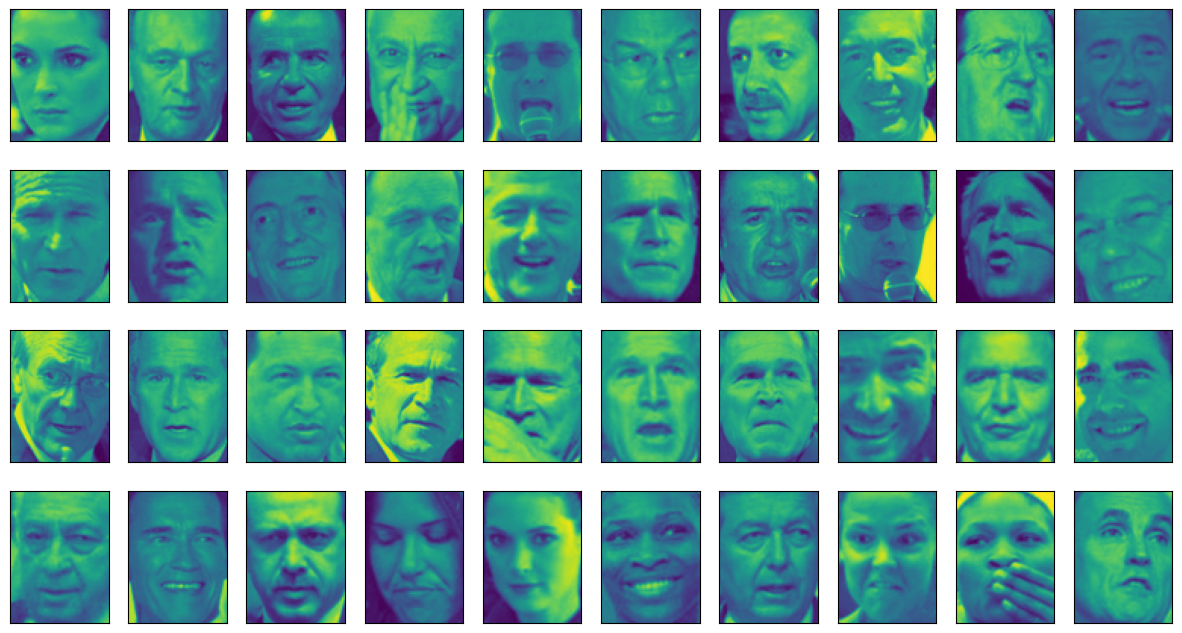

In [62]:
#ノイズがわずか37しかない
#これだけなら全部見ることができる

noise = X_people[labels==-1]

fig, axes = plt.subplots(4, 10, figsize=(15, 8),
                         subplot_kw={'xticks': (), 'yticks': ()})
for image,ax in zip(noise,axes.ravel()):
    ax.imshow(image.reshape(image_shape), vmin=0, vmax=1)
plt.show()

In [ ]:
#様々なepsの値でDBSCANを適用してみる

for eps in [1, 3, 5, 7, 9, 11, 13]:
    print("\neps={}".format(eps))
    dbscan = DBSCAN(eps=eps, min_samples=3)
    labels = dbscan.fit_predict(X_pca)
    print("Number of clusters: {}".format(len(np.unique(labels))))
    print("Cluster sizes: {}".format(np.bincount(labels + 1)))


eps=1
Number of clusters: 1
Cluster sizes: [2063]

eps=3
Number of clusters: 1
Cluster sizes: [2063]

eps=5
Number of clusters: 2
Cluster sizes: [2059    4]

eps=7
Number of clusters: 8
Cluster sizes: [1954   75    4   14    6    4    3    3]

eps=9
Number of clusters: 3
Cluster sizes: [1199  861    3]

eps=11
Number of clusters: 2
Cluster sizes: [ 403 1660]

eps=13
Number of clusters: 2
Cluster sizes: [ 119 1944]


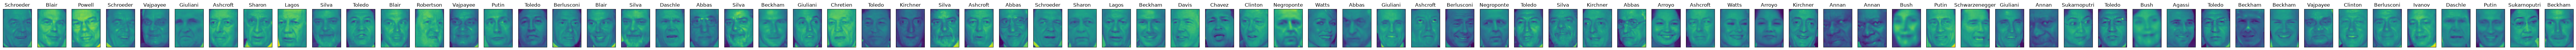

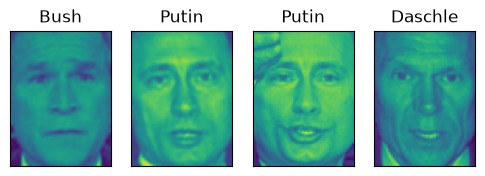

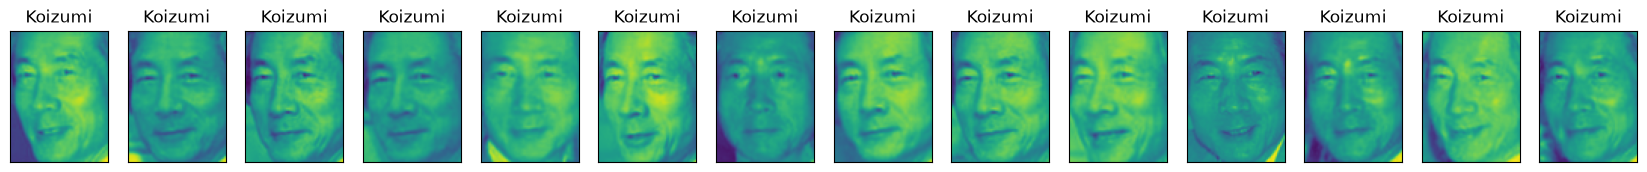

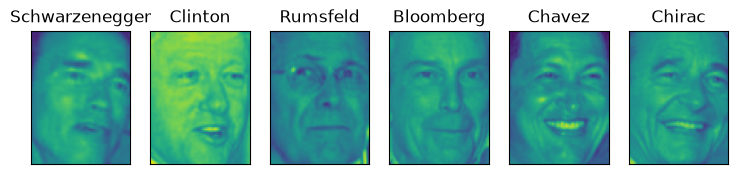

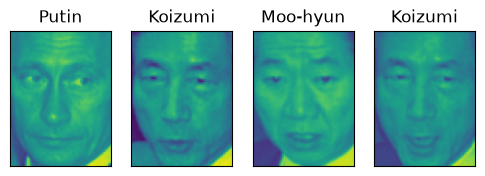

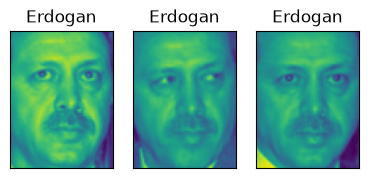

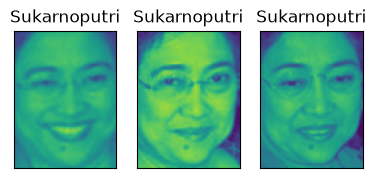

In [63]:
#一番興味深そうなeps=7でDBSCANを適用してみる

dbscan = DBSCAN(min_samples=3, eps=7)
labels = dbscan.fit_predict(X_pca)

for cluster in range(max(labels) + 1):
    mask = labels == cluster
    n_images =  np.sum(mask)
    fig, axes = plt.subplots(1, n_images, figsize=(n_images * 1.5, 4),
                             subplot_kw={'xticks': (), 'yticks': ()})
    for image, label, ax in zip(X_people[mask], y_people[mask], axes):

        ax.imshow(image.reshape(image_shape), vmin=0, vmax=1)
        ax.set_title(people.target_names[label].split()[-1])
plt.show()

**k-means法**

In [ ]:
#k-means法でクラスタを抽出
km = KMeans(n_clusters=10, random_state=0)
labels_km = km.fit_predict(X_pca)

#k-means法では、クラスタの大きさが比較的均等になる傾向がある
print("Cluster sizes k-means: {}".format(np.bincount(labels_km)))

Cluster sizes k-means: [  5 286 190 275 185 493   1 286   2 340]


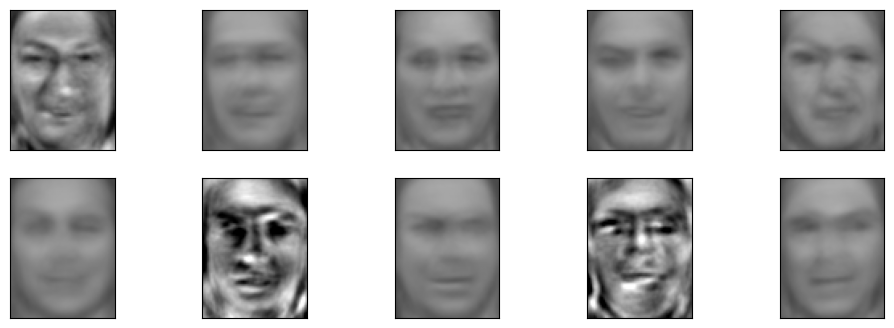

In [65]:
#クラスタ数を１０に設定してk-means法で見つけたクラスタセンタ
fig, axes = plt.subplots(
    2, 5,
    subplot_kw={'xticks': (), 'yticks': ()},
    figsize=(12, 4)
)

for center, ax in zip(km.cluster_centers_, axes.ravel()):
    image = pca.inverse_transform(center.reshape(1, -1))
    
    ax.imshow(
        image.reshape(image_shape),
        vmin=0, 
        vmax=1,
        cmap='gray'  
    ) 

plt.show()

**疑集型クラスタリング**

In [ ]:
#ward疑似的クラスタリングでクラスタを抽出

from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=10)
labels_agg = agg.fit_predict(X_pca)

#DBSCANよりもはるかに均等になっている
print("Cluster sizes agglomerative clustering: {}".format(np.bincount(labels_agg)))

Cluster sizes agglomerative clustering: [264 100 275 553  49  64 546  52  51 109]


In [ ]:
#疑集型クラスタリングとk-means法の結果の分割が似ているかどうかはARIスコアで評価できる
from sklearn.metrics import adjusted_rand_score

#ほとんど共通点がないことがわかる
print("ARI score between k-means and agglomerative clustering: {:.2f}".format(adjusted_rand_score(labels_km, labels_agg)))

ARI score between k-means and agglomerative clustering: 0.09


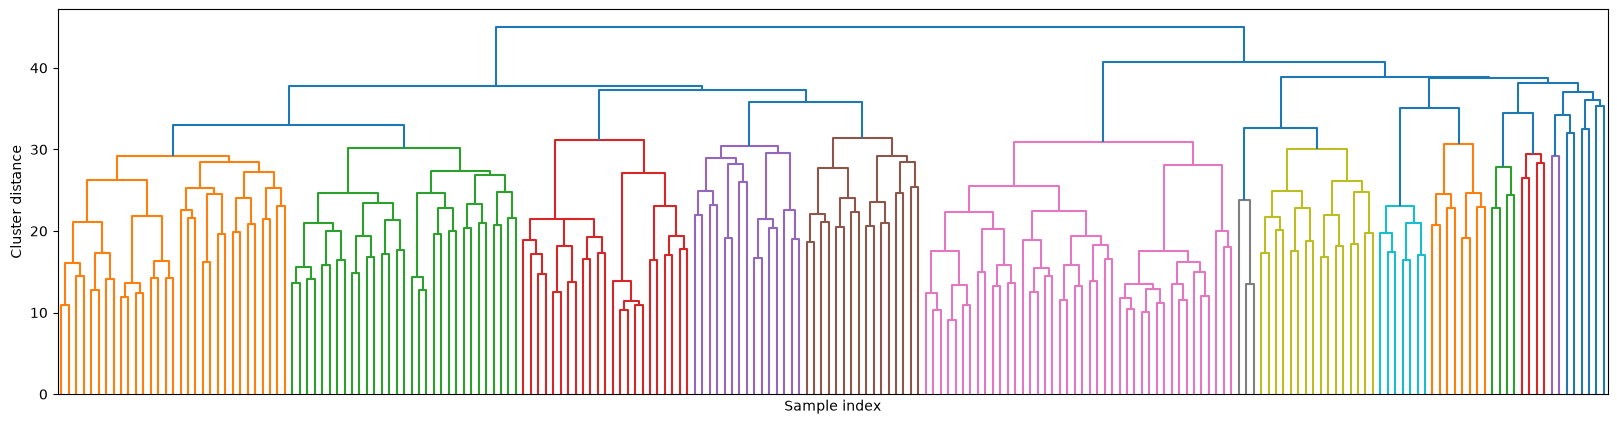

In [76]:
#デンドログラムで確認してみる
from scipy.cluster.hierarchy import dendrogram, ward
linkage_array = ward(X_pca)

plt.figure(figsize=(20, 5))
dendrogram(linkage_array, p=7, truncate_mode='level', no_labels=True)
plt.xlabel("Sample index")
plt.ylabel("Cluster distance")
plt.show()

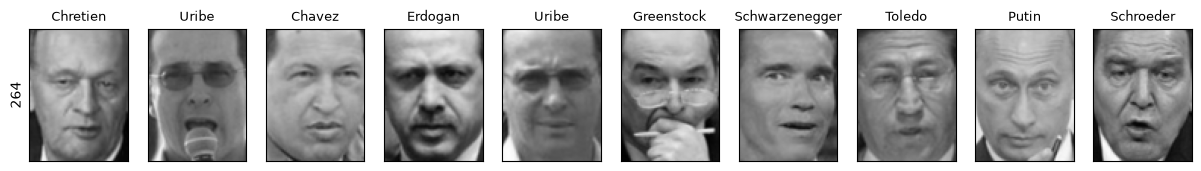

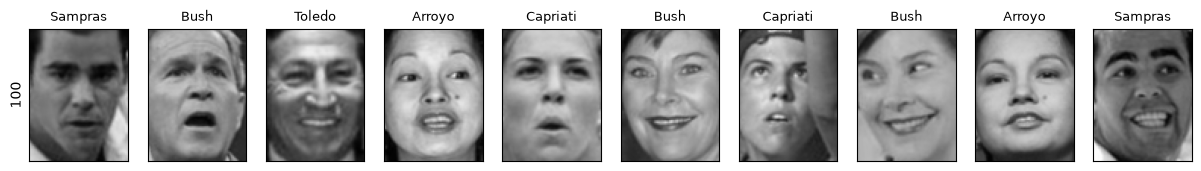

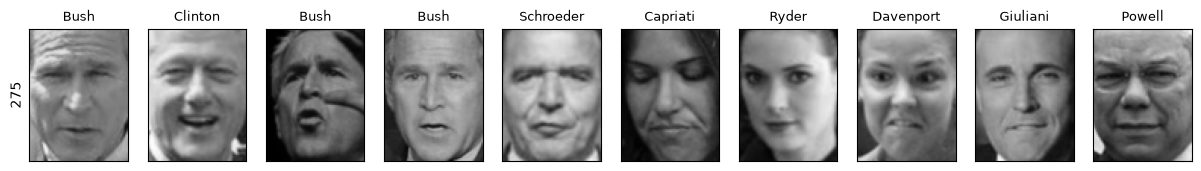

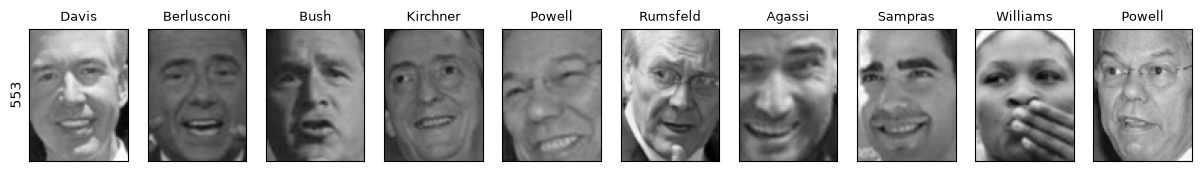

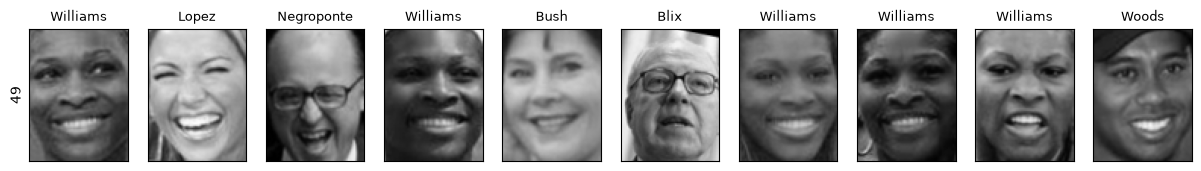

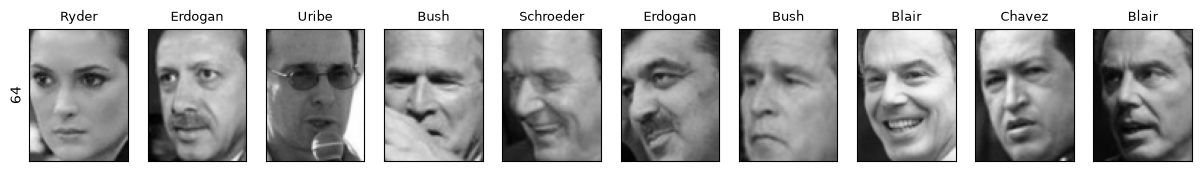

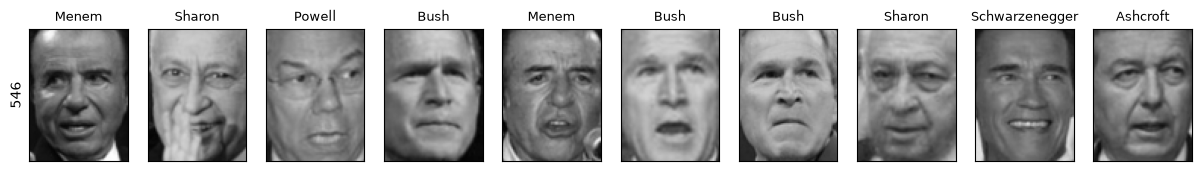

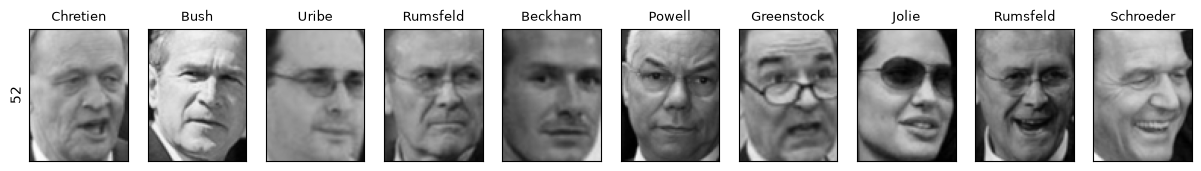

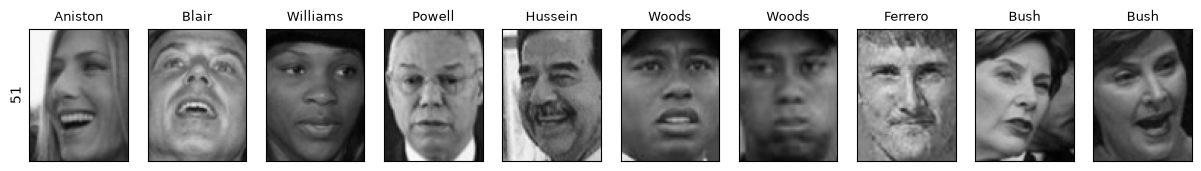

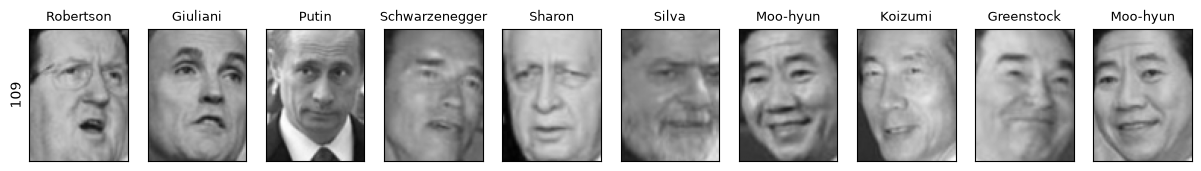

In [ ]:
#IN[82]で作られたクラスタからランダムに画像を表示したもの
#各行がクラスタに対応
#左の数字は、そのクラスタに存在する画像の数

n_clusters = 10
for cluster in range(n_clusters):
    mask = labels_agg == cluster
    fig, axes = plt.subplots(1, 10, subplot_kw={'xticks': (), 'yticks': ()},
                             figsize=(15, 8))
    axes[0].set_ylabel(np.sum(mask))
    for image, label, asdf, ax in zip(X_people[mask], y_people[mask],
                                      labels_agg[mask], axes):
        ax.imshow(image.reshape(image_shape), vmin=0, vmax=1, cmap='gray')
        ax.set_title(people.target_names[label].split()[-1],
                     fontdict={'fontsize': 9})
        
plt.show()

cluster sizes agglomerative clustering: [139  35  23   2 111  39 106  33   5 161  60  41  70  17  30  20 134  40
  23  38  56 264   4  35  44  16  29 135  25  37  42  34   3  17  31   3
  21  27  76  37]


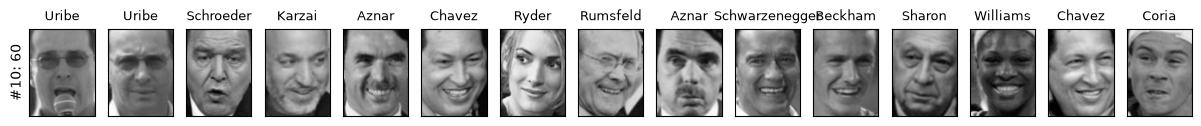

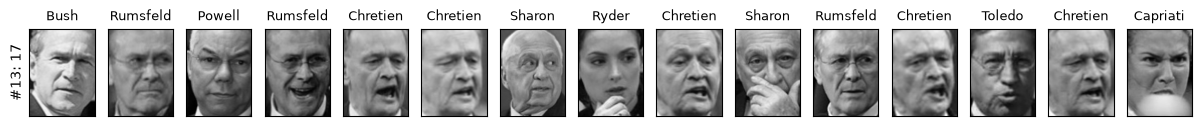

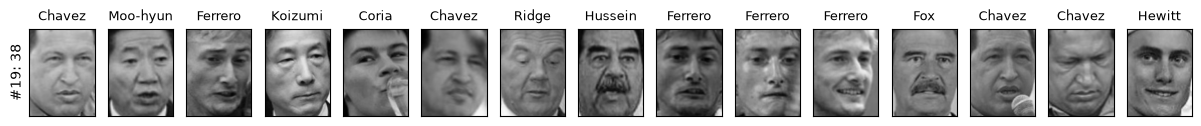

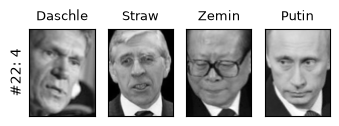

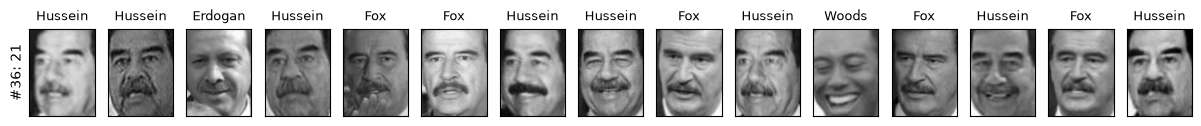

In [ ]:
#クラスタ数を４０に設定して、疑集型クラスタリングを行い、そのうち興味深いものを示す
#左にそのクラスタのインデックスと存在する画像の数を表示
#これらのクラスタは「濃色の肌で笑っている」、「襟付きのシャツ」、「笑っている女性」、「フセイン」、「おでこが広い」
# といような特徴を拾っているように見える

agglomerative = AgglomerativeClustering(n_clusters=40)
labels_agg = agglomerative.fit_predict(X_pca)
print("cluster sizes agglomerative clustering: {}".format(np.bincount(labels_agg)))

n_clusters = 40
for cluster in [10, 13, 19, 22, 36]: 
    mask = labels_agg == cluster
    fig, axes = plt.subplots(1, 15, subplot_kw={'xticks': (), 'yticks': ()},
                             figsize=(15, 8))
    cluster_size = np.sum(mask)
    axes[0].set_ylabel("#{}: {}".format(cluster, cluster_size))
    for image, label, asdf, ax in zip(X_people[mask], y_people[mask],
                                      labels_agg[mask], axes):
        ax.imshow(image.reshape(image_shape), vmin=0, vmax=1, cmap='gray')
        ax.set_title(people.target_names[label].split()[-1],
                     fontdict={'fontsize': 9})
    for i in range(cluster_size, 15):
        axes[i].set_visible(False)
        
plt.show()